STEP 1: Import Required Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import ssl
from scipy.fftpack import dct, idct, dst, idst

STEP 2: Load Grayscale Image

In [2]:
# ✅ Direct link conversion from: https://drive.google.com/file/d/1kWIx5TR65nuAIThAUgcn31ccBsOgVQW-/view
image_url = "https://drive.google.com/uc?export=download&id=1kWIx5TR65nuAIThAUgcn31ccBsOgVQW-"

context = ssl._create_unverified_context()
resp = urllib.request.urlopen(image_url, context=context)
image_bytes = np.asarray(bytearray(resp.read()), dtype=np.uint8)
gray = cv2.imdecode(image_bytes, cv2.IMREAD_GRAYSCALE)

if gray is None:
    raise Exception("❌ Image could not be loaded.")
else:
    print("✅ Image loaded successfully.")

# Convert to float32 for transforms
gray_f32 = np.float32(gray)

✅ Image loaded successfully.


STEP 3: DFT (Discrete Fourier Transform)


    📘 DFT converts spatial image data to frequency domain.
    📘 Formula:
        F(u,v) = ΣΣ f(x,y)·e^(-j·2π·(ux/M + vy/N))
        where f(x,y) is image intensity, and F(u,v) is frequency
    📘 Used for filtering, analysis, and compression.

In [3]:
dft = cv2.dft(gray_f32, flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)  # shift low freq to center
magnitude_dft = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)

# Inverse DFT (IDFT) to reconstruct image
dft_ishift = np.fft.ifftshift(dft_shift)
idft = cv2.idft(dft_ishift)
reconstructed_dft = cv2.magnitude(idft[:,:,0], idft[:,:,1])

STEP 4: DCT (Discrete Cosine Transform)


    📘 DCT expresses image as a sum of cosine functions.
    📘 Formula (2D):
        C(u,v) = α(u)α(v) ΣΣ f(x,y)·cos[(2x+1)uπ/2N]·cos[(2y+1)vπ/2M]
    📘 Used in JPEG compression due to energy compaction.

In [4]:
dct_trans = cv2.dct(gray_f32)
dct_log = np.log(np.abs(dct_trans) + 1)

# Inverse DCT (IDCT) to reconstruct image
idct_image = cv2.idct(dct_trans)

STEP 5: DST (Discrete Sine Transform)


    📘 DST uses sine basis and assumes odd symmetry.
    📘 Formula (1D):
        X(k) = Σ x(n)·sin[π(k+1)(n+1)/(N+1)]
    📘 Often used in signal processing and compression tasks.

In [5]:
# 2D DST using two 1D passes
dst_row = dst(gray_f32, type=2, axis=0, norm='ortho')
dst_2d  = dst(dst_row, type=2, axis=1, norm='ortho')
dst_log = np.log(np.abs(dst_2d) + 1)

# Inverse DST (IDST) using two 1D passes
idst_col = idst(dst_2d, type=2, axis=1, norm='ortho')
idst_image = idst(idst_col, type=2, axis=0, norm='ortho')

STEP 6: Display Original and Reconstructed Images

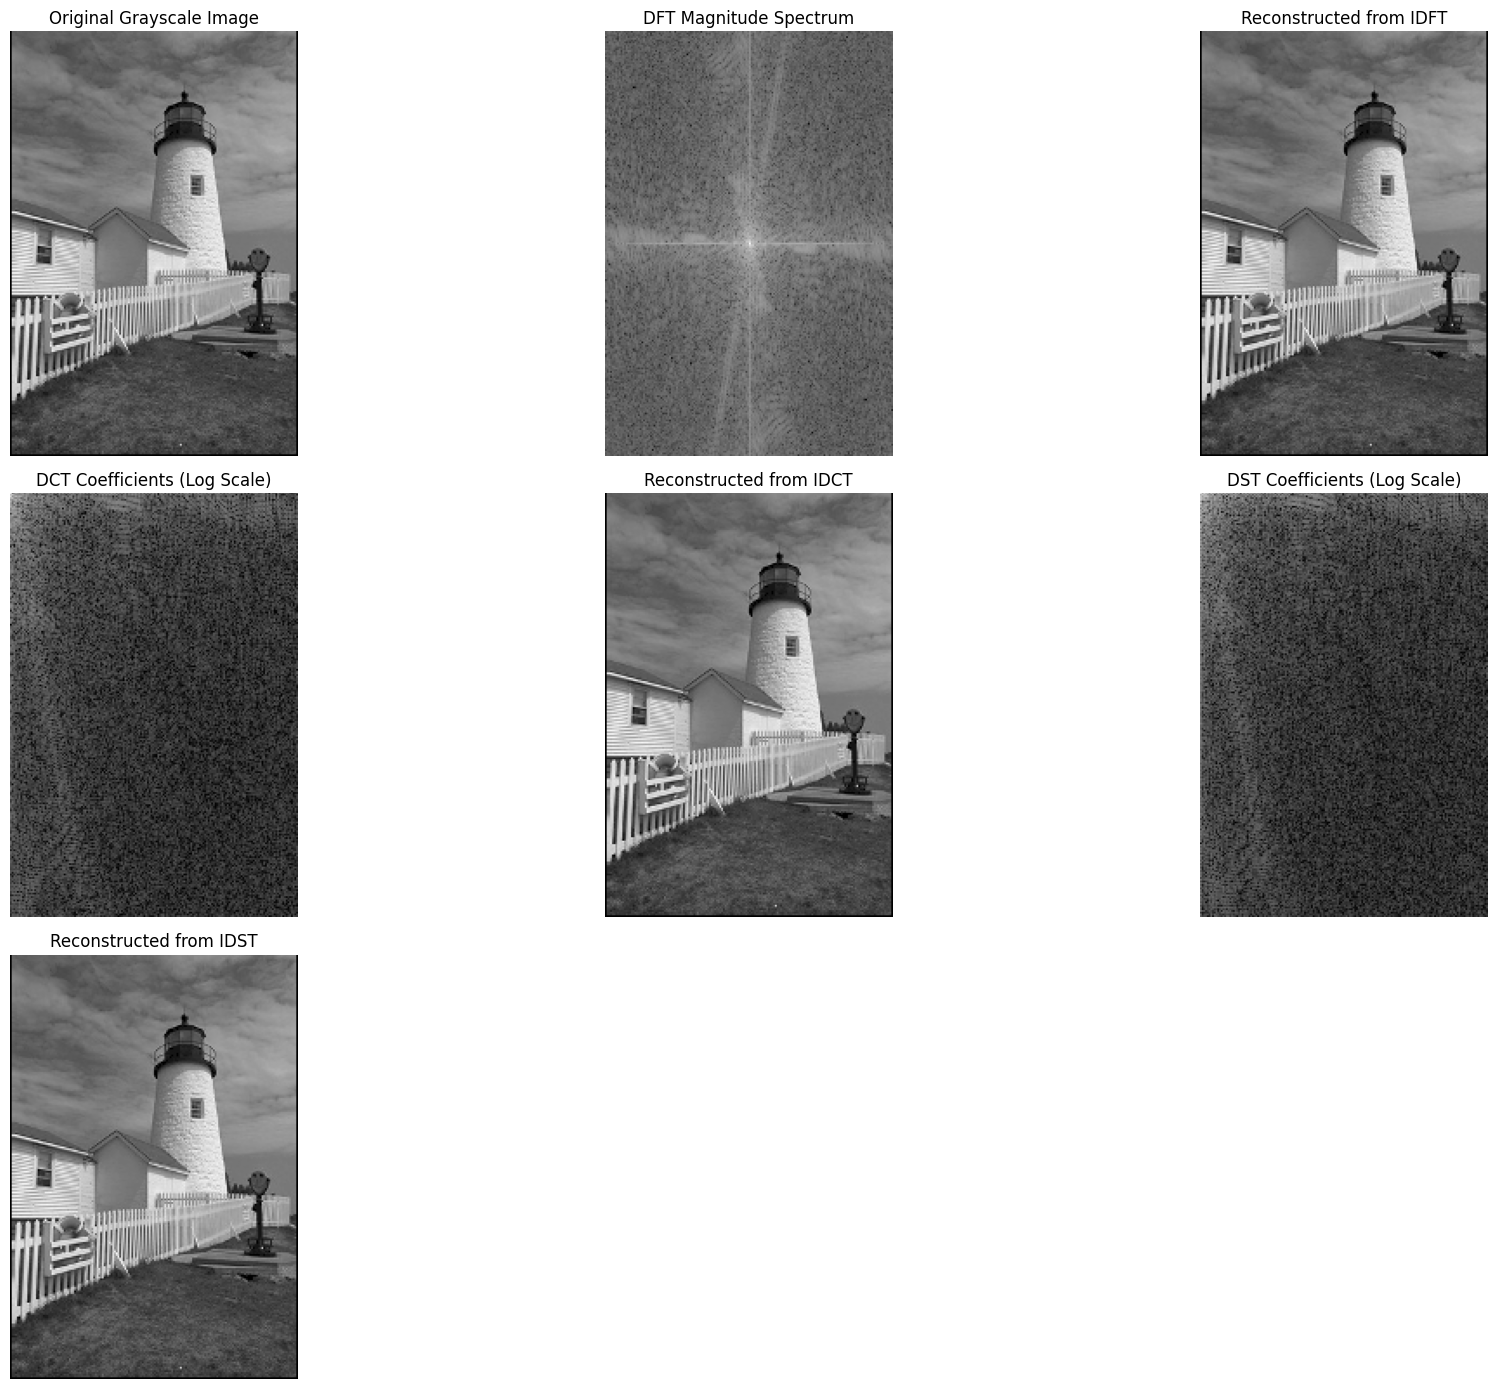

In [6]:
plt.figure(figsize=(18, 14))

# Original Image
plt.subplot(3, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')

# DFT Spectrum and IDFT
plt.subplot(3, 3, 2)
plt.imshow(magnitude_dft, cmap='gray')
plt.title("DFT Magnitude Spectrum")
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(reconstructed_dft, cmap='gray')
plt.title("Reconstructed from IDFT")
plt.axis('off')

# DCT and IDCT
plt.subplot(3, 3, 4)
plt.imshow(dct_log, cmap='gray')
plt.title("DCT Coefficients (Log Scale)")
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(idct_image, cmap='gray')
plt.title("Reconstructed from IDCT")
plt.axis('off')

# DST and IDST
plt.subplot(3, 3, 6)
plt.imshow(dst_log, cmap='gray')
plt.title("DST Coefficients (Log Scale)")
plt.axis('off')

plt.subplot(3, 3, 7)
plt.imshow(idst_image, cmap='gray')
plt.title("Reconstructed from IDST")
plt.axis('off')

plt.tight_layout()
plt.show()